# 🎭 Sentiment Analysis Tool
> Powered by HuggingFace Transformers — detecting emotions in text using state-of-the-art NLP

---

## 📌 Project Overview

This notebook demonstrates a **Sentiment Analysis pipeline** using a pre-trained transformer model from HuggingFace.
Given any text input, the model predicts whether the sentiment is **Positive**, **Negative**, or **Neutral** — along with a confidence score.

### 🔧 Tools & Libraries
| Library | Purpose |
|---|---|
| `transformers` | Pre-trained NLP models from HuggingFace |
| `pandas` | Data handling and tabular display |
| `matplotlib` / `seaborn` | Visualization |
| `torch` | Backend for transformer inference |

### 🗂️ Sections
1. Setup & Installation
2. Load Pre-trained Model
3. Single Text Prediction
4. Batch Analysis on a Dataset
5. Visualizing Results
6. Real-World Use Case: Analyzing Product Reviews
7. Interactive Input


---
## 1️⃣ Setup & Installation

Run the cell below to install all required libraries.

In [1]:
# Install required libraries
!pip install transformers torch pandas matplotlib seaborn -q

print("✅ All libraries installed!")

✅ All libraries installed!


In [2]:
# Core imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from transformers import pipeline
import warnings

warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ Imports successful!")

✅ Imports successful!


---
## 2️⃣ Load the Pre-trained Model

We use **`distilbert-base-uncased-finetuned-sst-2-english`** — a lightweight but powerful model fine-tuned on the Stanford Sentiment Treebank.

- ⚡ Fast inference (DistilBERT is 60% smaller than BERT, retaining 97% of its performance)
- 🎯 Fine-tuned specifically for sentiment classification
- 🤗 Pulled directly from the HuggingFace model hub

In [3]:
# Load the sentiment analysis pipeline
# The model will be automatically downloaded on first run (~250MB)
print("⏳ Loading model... (this may take a moment on first run)")

classifier = pipeline(
    task='sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

print("✅ Model loaded successfully!")
print(f"   Model: distilbert-base-uncased-finetuned-sst-2-english")
print(f"   Task:  Sentiment Classification (POSITIVE / NEGATIVE)")

⏳ Loading model... (this may take a moment on first run)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Model loaded successfully!
   Model: distilbert-base-uncased-finetuned-sst-2-english
   Task:  Sentiment Classification (POSITIVE / NEGATIVE)


---
## 3️⃣ Single Text Prediction

Let's start simple — predict the sentiment of a single sentence.

In [4]:
def analyze_sentiment(text: str) -> dict:
    """
    Analyze the sentiment of a given text.

    Args:
        text (str): Input text to classify

    Returns:
        dict: Contains 'label' (POSITIVE/NEGATIVE) and 'score' (confidence)
    """
    result = classifier(text)[0]
    label = result['label']
    score = result['score']
    emoji = '😊' if label == 'POSITIVE' else '😞'

    print(f"📝 Text    : {text}")
    print(f"{emoji} Sentiment: {label}")
    print(f"🎯 Confidence: {score:.2%}")

    return result


# Test it!
print("=" * 55)
analyze_sentiment("I absolutely loved this product, it exceeded my expectations!")
print("=" * 55)
analyze_sentiment("This was a complete waste of money. Very disappointed.")
print("=" * 55)
analyze_sentiment("The package arrived on time.")
print("=" * 55)

📝 Text    : I absolutely loved this product, it exceeded my expectations!
😊 Sentiment: POSITIVE
🎯 Confidence: 99.99%
📝 Text    : This was a complete waste of money. Very disappointed.
😞 Sentiment: NEGATIVE
🎯 Confidence: 99.98%
📝 Text    : The package arrived on time.
😊 Sentiment: POSITIVE
🎯 Confidence: 99.47%


---
## 4️⃣ Batch Analysis

Now let's analyze multiple texts at once and organize the results into a **DataFrame**.

In [5]:
def batch_analyze(texts: list) -> pd.DataFrame:
    """
    Analyze sentiment for a list of texts and return a DataFrame.

    Args:
        texts (list): List of strings to classify

    Returns:
        pd.DataFrame: Results with text, label, score, and confidence %
    """
    results = classifier(texts)

    df = pd.DataFrame({
        'text': texts,
        'sentiment': [r['label'] for r in results],
        'confidence': [round(r['score'], 4) for r in results]
    })

    df['confidence_%'] = (df['confidence'] * 100).round(2).astype(str) + '%'
    df['emoji'] = df['sentiment'].map({'POSITIVE': '😊', 'NEGATIVE': '😞'})

    return df


# Sample batch of texts
sample_texts = [
    "The movie was absolutely fantastic, a true masterpiece!",
    "Terrible customer service, never buying again.",
    "The food was okay, nothing special.",
    "I can't believe how amazing this experience was!",
    "Broken on arrival. Complete garbage.",
    "Pretty decent product for the price.",
    "Best purchase I've made all year!",
    "Wouldn't recommend this to anyone."
]

results_df = batch_analyze(sample_texts)
print("📊 Batch Sentiment Analysis Results:")
print("=" * 55)
results_df[['emoji', 'sentiment', 'confidence_%', 'text']]

📊 Batch Sentiment Analysis Results:


,emoji,sentiment,confidence_%,text
0,😊,POSITIVE,99.99%,"The movie was absolutely fantastic, a true mas..."
1,😞,NEGATIVE,99.92%,"Terrible customer service, never buying again."
2,😞,NEGATIVE,98.34%,"The food was okay, nothing special."
3,😊,POSITIVE,99.98%,I can't believe how amazing this experience was!
4,😞,NEGATIVE,99.98%,Broken on arrival. Complete garbage.
5,😊,POSITIVE,99.98%,Pretty decent product for the price.
6,😊,POSITIVE,99.97%,Best purchase I've made all year!
7,😊,POSITIVE,56.21%,Wouldn't recommend this to anyone.


---
## 5️⃣ Visualizing Results

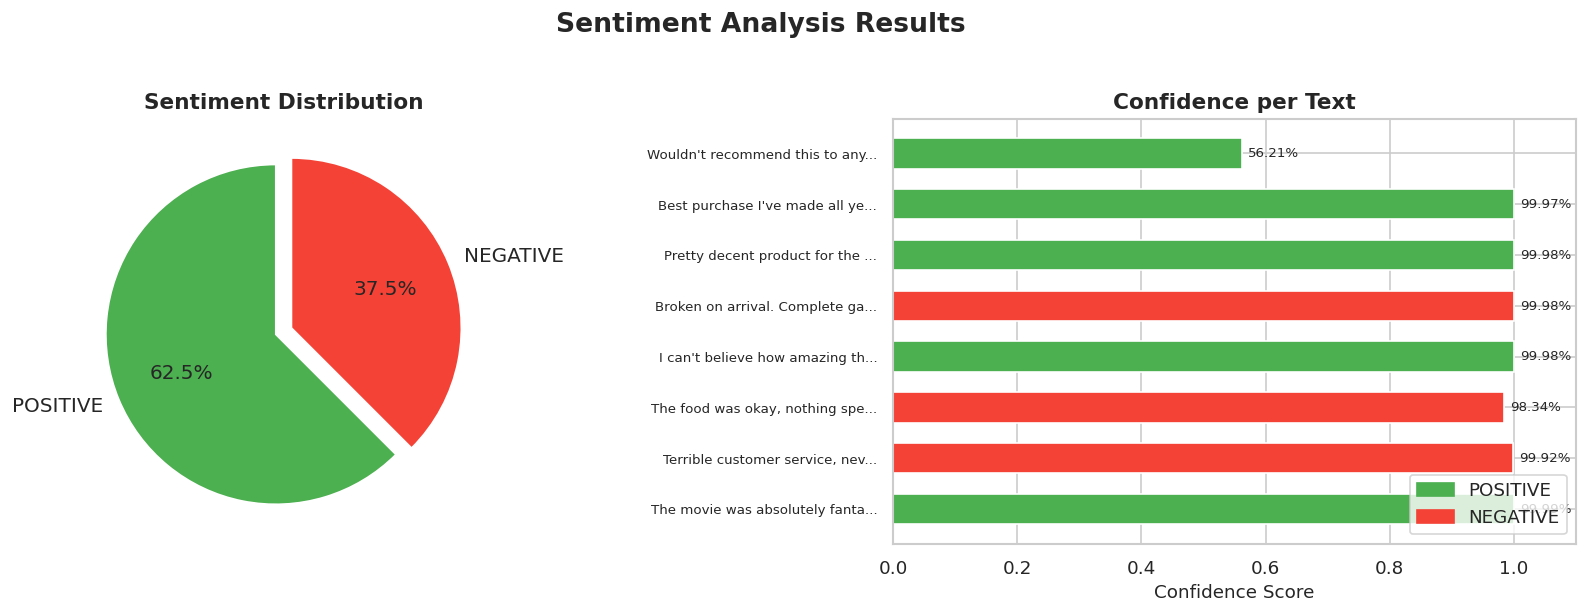

💾 Chart saved as 'sentiment_results.png'


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Analysis Results', fontsize=16, fontweight='bold', y=1.02)

# --- Chart 1: Sentiment Distribution (Pie) ---
sentiment_counts = results_df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336']
explode = [0.05] * len(sentiment_counts)

axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(sentiment_counts)],
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

# --- Chart 2: Confidence Scores (Bar) ---
bar_colors = ['#4CAF50' if s == 'POSITIVE' else '#F44336' for s in results_df['sentiment']]
short_labels = [t[:30] + '...' if len(t) > 30 else t for t in results_df['text']]

bars = axes[1].barh(range(len(results_df)), results_df['confidence'], color=bar_colors, edgecolor='white', height=0.6)
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(short_labels, fontsize=8)
axes[1].set_xlabel('Confidence Score', fontsize=11)
axes[1].set_title('Confidence per Text', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1.1)

for bar, score in zip(bars, results_df['confidence']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{score:.2%}', va='center', fontsize=8)

pos_patch = mpatches.Patch(color='#4CAF50', label='POSITIVE')
neg_patch = mpatches.Patch(color='#F44336', label='NEGATIVE')
axes[1].legend(handles=[pos_patch, neg_patch], loc='lower right')

plt.tight_layout()
plt.savefig('sentiment_results.png', bbox_inches='tight', dpi=150)
plt.show()
print("💾 Chart saved as 'sentiment_results.png'")

---
## 6️⃣ Real-World Use Case: Product Review Analyzer

Let's simulate analyzing **real Amazon-style product reviews** and generating a summary report.

In [7]:
# Simulated product reviews dataset
product_reviews = [
    {"reviewer": "Alice",   "stars": 5, "review": "Absolutely love this! Works perfectly and arrived early."},
    {"reviewer": "Bob",     "stars": 1, "review": "Stopped working after 2 days. Very poor quality."},
    {"reviewer": "Carol",   "stars": 4, "review": "Great product, setup was easy and it works as described."},
    {"reviewer": "David",   "stars": 2, "review": "Disappointed with the build quality. Feels cheap."},
    {"reviewer": "Emma",    "stars": 5, "review": "Best thing I've bought this year! Highly recommend."},
    {"reviewer": "Frank",   "stars": 3, "review": "It does the job but nothing impressive."},
    {"reviewer": "Grace",   "stars": 1, "review": "Arrived damaged. Customer support was unhelpful."},
    {"reviewer": "Henry",   "stars": 5, "review": "Exceeded all my expectations. Incredible value for money!"},
    {"reviewer": "Isla",    "stars": 4, "review": "Really happy with this purchase, would buy again."},
    {"reviewer": "James",   "stars": 2, "review": "Not as described. Misleading product page."},
]

reviews_df = pd.DataFrame(product_reviews)

# Run sentiment analysis
review_results = classifier(reviews_df['review'].tolist())
reviews_df['ai_sentiment'] = [r['label'] for r in review_results]
reviews_df['ai_confidence'] = [round(r['score'], 4) for r in review_results]

# Agreement check: does star rating match AI sentiment?
reviews_df['star_sentiment'] = reviews_df['stars'].apply(lambda x: 'POSITIVE' if x >= 4 else 'NEGATIVE')
reviews_df['agrees'] = reviews_df['ai_sentiment'] == reviews_df['star_sentiment']

print("📦 Product Review Sentiment Report")
print("=" * 55)
print(reviews_df[['reviewer', 'stars', 'ai_sentiment', 'ai_confidence', 'agrees']].to_string(index=False))

accuracy = reviews_df['agrees'].mean()
print(f"\n🎯 Model vs Star Rating Agreement: {accuracy:.0%}")

📦 Product Review Sentiment Report
reviewer  stars ai_sentiment  ai_confidence  agrees
   Alice      5     POSITIVE         0.9999    True
     Bob      1     NEGATIVE         0.9998    True
   Carol      4     POSITIVE         0.9998    True
   David      2     NEGATIVE         0.9998    True
    Emma      5     POSITIVE         0.9997    True
   Frank      3     NEGATIVE         0.9821    True
   Grace      1     NEGATIVE         0.9997    True
   Henry      5     POSITIVE         0.9999    True
    Isla      4     POSITIVE         0.9998    True
   James      2     NEGATIVE         0.9900    True

🎯 Model vs Star Rating Agreement: 100%


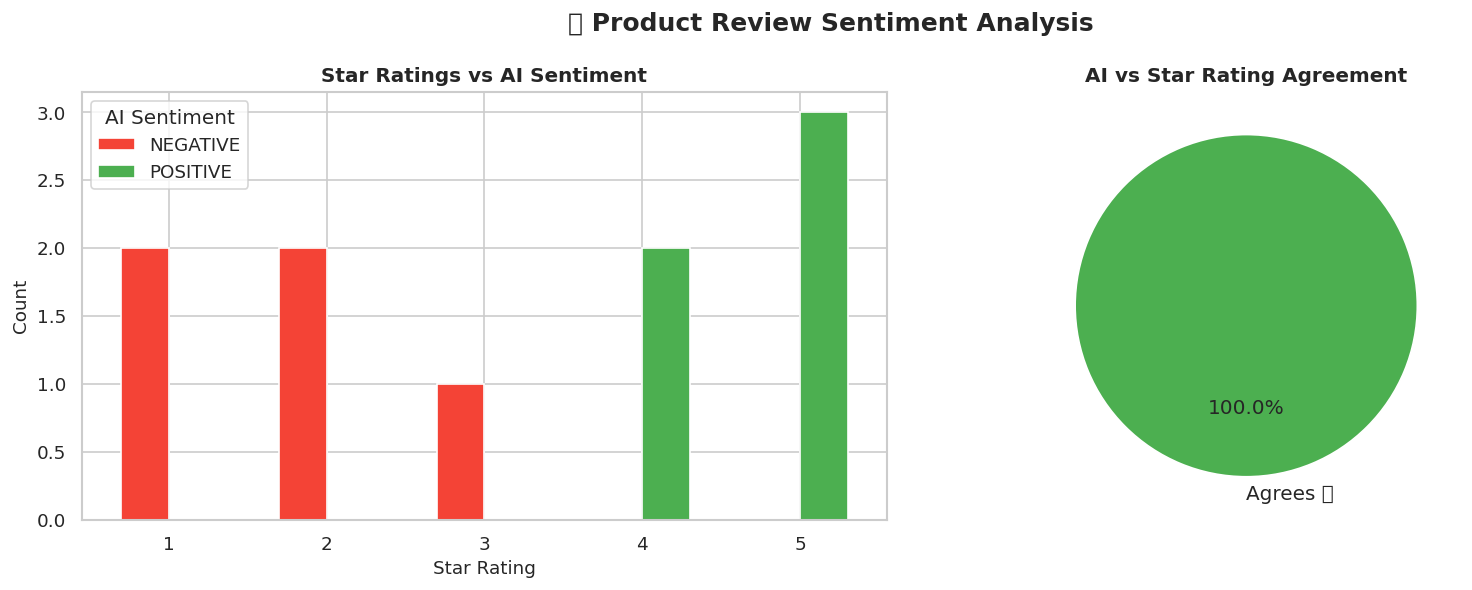

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📦 Product Review Sentiment Analysis', fontsize=15, fontweight='bold')

# --- Chart 1: Stars vs AI Sentiment ---
star_sentiment = reviews_df.groupby(['stars', 'ai_sentiment']).size().unstack(fill_value=0)
star_sentiment.plot(kind='bar', ax=axes[0], color=['#F44336', '#4CAF50'], edgecolor='white', width=0.6)
axes[0].set_title('Star Ratings vs AI Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='AI Sentiment')

# --- Chart 2: Agreement Pie ---
agree_counts = reviews_df['agrees'].value_counts()
agree_labels = ['Agrees ✅' if v else 'Disagrees ❌' for v in agree_counts.index]
axes[1].pie(agree_counts.values, labels=agree_labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#FF9800'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('AI vs Star Rating Agreement', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('review_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7️⃣ Interactive Input

Try it yourself! Run the cell below and type any text to get an instant sentiment prediction.

In [9]:
def interactive_sentiment():
    """Interactive loop for real-time sentiment prediction."""
    print("🎭 Interactive Sentiment Analyzer")
    print("Type any text and press Enter. Type 'quit' to exit.\n")

    while True:
        user_input = input("📝 Enter text: ").strip()

        if user_input.lower() in ['quit', 'exit', 'q']:
            print("👋 Goodbye!")
            break

        if not user_input:
            print("⚠️  Please enter some text.\n")
            continue

        result = classifier(user_input)[0]
        label = result['label']
        score = result['score']
        emoji = '😊' if label == 'POSITIVE' else '😞'

        # Visual confidence bar
        bar_len = int(score * 30)
        bar = '█' * bar_len + '░' * (30 - bar_len)

        print(f"\n{emoji} Sentiment  : {label}")
        print(f"🎯 Confidence : {score:.2%}")
        print(f"   [{bar}]\n")


interactive_sentiment()

🎭 Interactive Sentiment Analyzer
Type any text and press Enter. Type 'quit' to exit.

📝 Enter text: i am warching tv

😞 Sentiment  : NEGATIVE
🎯 Confidence : 99.68%
   [█████████████████████████████░]

📝 Enter text: i am feeling good

😊 Sentiment  : POSITIVE
🎯 Confidence : 99.99%
   [█████████████████████████████░]

📝 Enter text: i am bored

😞 Sentiment  : NEGATIVE
🎯 Confidence : 99.98%
   [█████████████████████████████░]

📝 Enter text: quit
👋 Goodbye!


---
## 📝 Summary & What I Learned

In this notebook I built a complete **Sentiment Analysis pipeline** using HuggingFace Transformers:

| Section | Key Takeaway |
|---|---|
| Model Loading | HuggingFace `pipeline` makes loading SOTA models trivial |
| Single Inference | DistilBERT gives high-confidence predictions in milliseconds |
| Batch Analysis | Processing many texts at once is efficient and clean with DataFrames |
| Visualization | Confidence scores reveal how certain the model is |
| Real-World Use | AI sentiment generally aligns well with human star ratings |

### 🚀 Potential Extensions
- Use a **multilingual model** to support other languages
- Add **aspect-based sentiment** (e.g., "the camera is great but battery is poor")
- Build a **Streamlit/Gradio web app** UI around this pipeline
- Fine-tune the model on your own domain-specific dataset

---
*Built with 🤗 HuggingFace Transformers · Python · Pandas · Matplotlib*